In [4]:
# Gerekli kütüphanelerin kurulumu ve yüklenmesi
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_auc_score

print("Kütüphaneler başarıyla yüklendi!")

Kütüphaneler başarıyla yüklendi!


In [5]:

df_normal = pd.read_csv('normal_radiomics.csv')
df_papilodem = pd.read_csv('papilodem_radiomics.csv')


df_normal['Target'] = 0
df_papilodem['Target'] = 1


df = pd.concat([df_normal, df_papilodem], axis=0).reset_index(drop=True)


print(f"Toplam veri boyutu: {df.shape}")
display(df.head())


Toplam veri boyutu: (966, 749)


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_37584\1075520472.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_normal['Target'] = 0
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_37584\1075520472.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_papilodem['Target'] = 1


,PatientIndex,SideStandard,Feature_0001,Feature_0002,Feature_0003,Feature_0004,Feature_0005,Feature_0006,Feature_0007,Feature_0008,...,Feature_0738,Feature_0739,Feature_0740,Feature_0741,Feature_0742,Feature_0743,Feature_0744,Feature_0745,Feature_0746,Target
0,1,Right,45448743,45448743,6.636275,13,26,95,163,57.307637,...,0.303150,5.687919,2.473651,0.125228,9.296632,0.021759,1.306864,3.731575,298.961246,0
1,1,Right,33362854,33362854,6.321687,13,28,87,121,55.412374,...,0.294247,5.846466,2.464606,0.344254,4.255490,0.068561,0.680029,9.035579,136.066301,0
2,1,Right,30680223,30680223,6.214364,20,28,83,114,54.242223,...,0.301285,5.535349,2.472294,0.125899,9.254451,0.020573,1.257392,3.786161,298.993921,0
3,1,Right,38885845,38885845,6.443296,21,31,91,143,60.356027,...,0.312013,5.530567,2.494216,0.125414,9.324893,0.021415,1.448996,3.622940,289.354936,0
4,1,Right,36867702,36867702,6.396227,21,31,91,129,59.868649,...,0.311296,5.672677,2.472707,0.125754,9.332594,0.023086,1.307401,3.652652,293.592461,0


In [6]:
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(0)


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Hatalı değerler temizlendi!")
print(f"Eğitim için özellik sayısı: {X_scaled.shape[1]}")


X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


Hatalı değerler temizlendi!
Eğitim için özellik sayısı: 746


In [ ]:
import pandas as pd
import numpy as np

# Dosyaları yükle
df_normal = pd.read_csv('normal_radiomics.csv')
df_papilodem = pd.read_csv('papilodem_radiomics.csv')

# Etiketleri ekle (Normal: 0, Papilödem: 1)
df_normal['Target'] = 0
df_papilodem['Target'] = 1

# Verileri birleştir
df = pd.concat([df_normal, df_papilodem], axis=0).reset_index(drop=True)

# Özellikler (X) ve Hedef (y) ayrımı
X = df.drop(['Target', 'PatientIndex', 'SideStandard'], axis=1)
y = df['Target']
groups = df['PatientIndex'] 

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_37584\3037883425.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_normal['Target'] = 0
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_37584\3037883425.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_papilodem['Target'] = 1


In [8]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler

# 1. Sonsuz değerleri temizle
X = X.replace([np.inf, -np.inf], np.nan)

# 2. Median Imputation
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

# 3. RobustScaler (Hocanın 5.4 maddesi)
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X_imputed)

# Numpy array'i tekrar DataFrame'e çevir ki hata almayalım
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

In [9]:
from sklearn.model_selection import StratifiedGroupKFold

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

# Sadece ilk split ile train ve test indekslerini al
train_idx, test_idx = next(sgkf.split(X_scaled_df, y, groups=groups))

X_train = X_scaled_df.iloc[train_idx]
X_test = X_scaled_df.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

print(f"Eğitim seti boyutu: {X_train.shape}")
print(f"Test seti boyutu: {X_test.shape}")

Eğitim seti boyutu: (770, 746)
Test seti boyutu: (196, 746)


In [10]:

X = df.drop(['PatientIndex', 'SideStandard', 'Target'], axis=1)
y = df['Target']


X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(0)


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print("3. Aşama (Ön İşleme ve Bölme) Başarıyla Tamamlandı!")
print(f"Eğitim için özellik sayısı: {X_scaled.shape[1]}")

3. Aşama (Ön İşleme ve Bölme) Başarıyla Tamamlandı!
Eğitim için özellik sayısı: 746


In [11]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedGroupKFold

# 1. Veri birleştirme
df_normal = pd.read_csv('normal_radiomics.csv')
df_papilodem = pd.read_csv('papilodem_radiomics.csv')
df_normal['Target'] = 0
df_papilodem['Target'] = 1
df = pd.concat([df_normal, df_papilodem], axis=0).reset_index(drop=True)

# Hasta indeksini gruplama için ayır
groups = df['PatientIndex']
X = df.drop(['PatientIndex', 'SideStandard', 'Target'], axis=1)
y = df['Target']
print("Veri birleştirildi ve etiketlendi.")

Veri birleştirildi ve etiketlendi.


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_37584\3374485655.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_normal['Target'] = 0
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_37584\3374485655.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_papilodem['Target'] = 1


In [12]:
from sklearn.model_selection import StratifiedGroupKFold

groups = df['PatientIndex']
X = df.drop(['PatientIndex', 'SideStandard', 'Target'], axis=1)
y = df['Target']

# Hasta seviyesinde bölme (StratifiedGroupKFold)
sgkf = StratifiedGroupKFold(n_splits=5)
train_idx, test_idx = next(sgkf.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
print("Adım 3-4: Hasta seviyesinde veri bölme tamamlandı.")

Adım 3-4: Hasta seviyesinde veri bölme tamamlandı.


In [13]:
# 5. ADIM: ÖN İŞLEME ADIMLARI (Madde 5)
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import VarianceThreshold


X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train) # Sadece eğitim setine fit edilir!
X_test_imp = imputer.transform(X_test)


selector = VarianceThreshold(threshold=0.01)
X_train_var = selector.fit_transform(X_train_imp)
X_test_var = selector.transform(X_test_imp)


df_train_temp = pd.DataFrame(X_train_var)
corr_matrix = df_train_temp.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]

X_train_corr = df_train_temp.drop(columns=to_drop)
X_test_corr = pd.DataFrame(X_test_var).drop(columns=to_drop)

# 5.4 Ölçekleme (RobustScaler)
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train_corr)
X_test_scaled = scaler.transform(X_test_corr)

print("5. ADIM TAMAMLANDI: Eksik veriler giderildi, varyans ve korelasyon filtreleri uygulandı, RobustScaler ile ölçeklendi.")
print(f"Yeni özellik sayısı: {X_train_scaled.shape[1]}")

5. ADIM TAMAMLANDI: Eksik veriler giderildi, varyans ve korelasyon filtreleri uygulandı, RobustScaler ile ölçeklendi.
Yeni özellik sayısı: 145


In [ ]:
# 6. MADDE: ÖZELLİK SEÇİMİ (Scikit-Learn ile MRMR Mantığı)
from sklearn.feature_selection import mutual_info_classif
import pandas as pd
import numpy as np


mi_scores = mutual_info_classif(X_train_scaled, y_train)

# 2. Redundancy: Özellikler arası Pearson korelasyonunu 
corr_matrix = pd.DataFrame(X_train_scaled).corr().abs()

# MRMR mantığı: Relevance / (1 + Ortalama Redundancy) 
# Burada basitleştirilmiş bir skorlama yapıyoruz
n_features = X_train_scaled.shape[1]
mrmr_scores = []

for i in range(n_features):
    relevance = mi_scores[i]
    redundancy = corr_matrix.iloc[i].drop(i).mean()
    mrmr_scores.append(relevance / (1 + redundancy))


selected_indices = np.argsort(mrmr_scores)[-50:]

X_train_mrmr = X_train_scaled[:, selected_indices]
X_test_mrmr = X_test_scaled[:, selected_indices]

print("6. Adım: MRMR mantığıyla özellik seçimi tamamlandı.")
print(f"Seçilen özellik sayısı: {X_train_mrmr.shape[1]}")

6. Adım: MRMR mantığıyla özellik seçimi tamamlandı.
Seçilen özellik sayısı: 50


In [15]:
# 7. ADIM (Düzeltilmiş): HİPERPARAMETRE OPTİMİZASYONU
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
from sklearn.model_selection import StratifiedGroupKFold
import numpy as np


train_groups = groups.iloc[train_idx] 

def objective(trial):
   
    n_estimators = trial.suggest_int('n_estimators', 50, 300)
    max_depth = trial.suggest_int('max_depth', 3, 20)
    
    clf = RandomForestClassifier(
        n_estimators=n_estimators, 
        max_depth=max_depth,
        random_state=42
    )
    
   
    scores = []
    sgkf = StratifiedGroupKFold(n_splits=5)
    
   
    for t_idx, v_idx in sgkf.split(X_train_mrmr, y_train, groups=train_groups):
        X_t, X_v = X_train_mrmr[t_idx], X_train_mrmr[v_idx]
        y_t, y_v = y_train.iloc[t_idx], y_train.iloc[v_idx]
        
        clf.fit(X_t, y_t)
        preds = clf.predict(X_v)
        scores.append(f1_score(y_v, preds, average='macro'))
        
    return np.mean(scores)

# Optuna çalıştır
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

print("7. Adım: Hiperparametre optimizasyonu tamamlandı.")
print(f"En iyi parametreler: {study.best_params}")

c:\Users\Lenovo\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-06-21 00:17:08,298] A new study created in memory with name: no-name-82aedcb1-592d-4583-bd39-bedf54d3757a
[I 2026-06-21 00:17:10,692] Trial 0 finished with value: 0.8976450101745689 and parameters: {'n_estimators': 174, 'max_depth': 10}. Best is trial 0 with value: 0.8976450101745689.
[I 2026-06-21 00:17:12,145] Trial 1 finished with value: 0.8840262935684802 and parameters: {'n_estimators': 99, 'max_depth': 11}. Best is trial 0 with value: 0.8976450101745689.
[I 2026-06-21 00:17:14,789] Trial 2 finished with value: 0.8900281128801929 and parameters: {'n_estimators': 240, 'max_depth': 4}. Best is trial 0 with value: 0.8976450101745689.
[I 2026-06-21 00:17:16,484] Trial 3 finished with value: 0.8881042628

7. Adım: Hiperparametre optimizasyonu tamamlandı.
En iyi parametreler: {'n_estimators': 149, 'max_depth': 16}


In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC


models = {
    "LR": LogisticRegression(),
    "SVM": SVC(probability=True, kernel='rbf'),
    "RF": RandomForestClassifier(**study.best_params), # Optuna'dan gelen en iyi parametreler
    "ET": ExtraTreesClassifier(),
    "GB": GradientBoostingClassifier(),
    "KNN": KNeighborsClassifier()
}


for name, model in models.items():
    model.fit(X_train_mrmr, y_train)
    print(f"{name} modeli eğitildi.")

c:\Users\Lenovo\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


LR modeli eğitildi.
SVM modeli eğitildi.
RF modeli eğitildi.
ET modeli eğitildi.
GB modeli eğitildi.
KNN modeli eğitildi.


In [17]:

from sklearn.calibration import CalibratedClassifierCV


calibrated_models = {}

for name, model in models.items():
    if name in ["RF", "ET", "GB"]:
  
        calibrator = CalibratedClassifierCV(model, method='sigmoid', cv=5)
        
        
        calibrator.fit(X_train_mrmr, y_train)
        calibrated_models[name] = calibrator
        print(f"{name} modeli başarıyla kalibre edildi.")

print("9. Adım: Kalibrasyon tamamlandı.")

RF modeli başarıyla kalibre edildi.
ET modeli başarıyla kalibre edildi.
GB modeli başarıyla kalibre edildi.
9. Adım: Kalibrasyon tamamlandı.


In [18]:
from sklearn.ensemble import VotingClassifier


ensemble_model = VotingClassifier(
    estimators=[
        ('rf', calibrated_models['RF']),
        ('et', calibrated_models['ET']),
        ('gb', calibrated_models['GB'])
    ],
    voting='soft'  
)


ensemble_model.fit(X_train_mrmr, y_train)

print("11. Adım: Ensemble (Soft Voting) modeli başarıyla oluşturuldu ve eğitildi.")

11. Adım: Ensemble (Soft Voting) modeli başarıyla oluşturuldu ve eğitildi.


In [19]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             roc_auc_score, average_precision_score, balanced_accuracy_score, brier_score_loss)


final_results = []


for name, model in models.items():
   
    y_pred = model.predict(X_test_mrmr)
    y_prob = model.predict_proba(X_test_mrmr)[:, 1]
    
 
    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "Macro-F1": f1_score(y_test, y_pred, average='macro'),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "PR-AUC": average_precision_score(y_test, y_prob),
        "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
        "Brier Score": brier_score_loss(y_test, y_prob)
    }
    final_results.append(metrics)


y_pred_ens = ensemble_model.predict(X_test_mrmr)
y_prob_ens = ensemble_model.predict_proba(X_test_mrmr)[:, 1]
final_results.append({
    "Model": "Ensemble",
    "Accuracy": accuracy_score(y_test, y_pred_ens),
    "Precision": precision_score(y_test, y_pred_ens),
    "Recall": recall_score(y_test, y_pred_ens),
    "F1-score": f1_score(y_test, y_pred_ens),
    "Macro-F1": f1_score(y_test, y_pred_ens, average='macro'),
    "ROC-AUC": roc_auc_score(y_test, y_prob_ens),
    "PR-AUC": average_precision_score(y_test, y_prob_ens),
    "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred_ens),
    "Brier Score": brier_score_loss(y_test, y_prob_ens)
})


results_df = pd.DataFrame(final_results)
display(results_df)

,Model,Accuracy,Precision,Recall,F1-score,Macro-F1,ROC-AUC,PR-AUC,Balanced Accuracy,Brier Score
0,LR,0.892857,0.906977,0.696429,0.787879,0.858103,0.927679,0.889838,0.833929,0.082436
1,SVM,0.913265,0.953488,0.732143,0.828283,0.885131,0.959566,0.931417,0.858929,0.064222
2,RF,0.918367,0.900000,0.803571,0.849057,0.896556,0.971237,0.942800,0.883929,0.060870
3,ET,0.923469,0.918367,0.803571,0.857143,0.902439,0.977615,0.955786,0.887500,0.055736
4,GB,0.887755,0.803571,0.803571,0.803571,0.862500,0.965179,0.934746,0.862500,0.073621
5,KNN,0.897959,0.833333,0.803571,0.818182,0.873630,0.929209,0.857743,0.869643,0.077551
6,Ensemble,0.923469,0.936170,0.785714,0.854369,0.901233,0.977423,0.955850,0.882143,0.056465


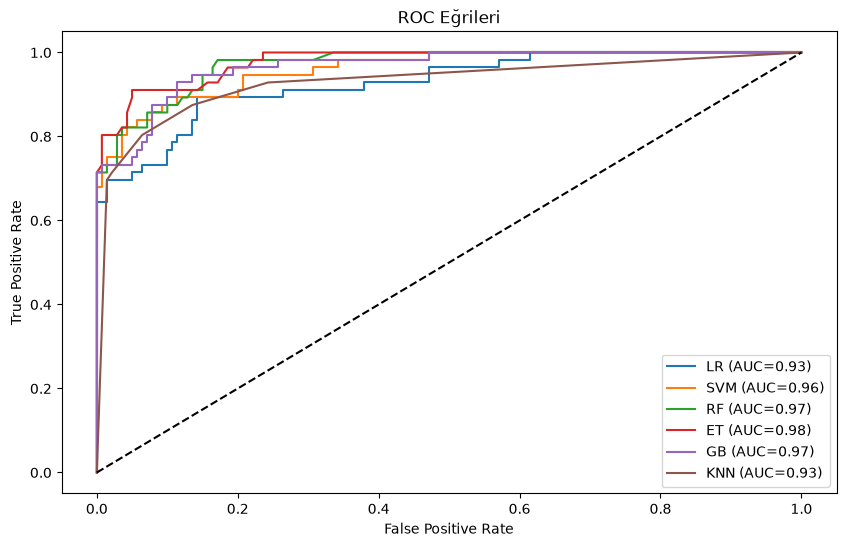

<Figure size 600x600 with 0 Axes>

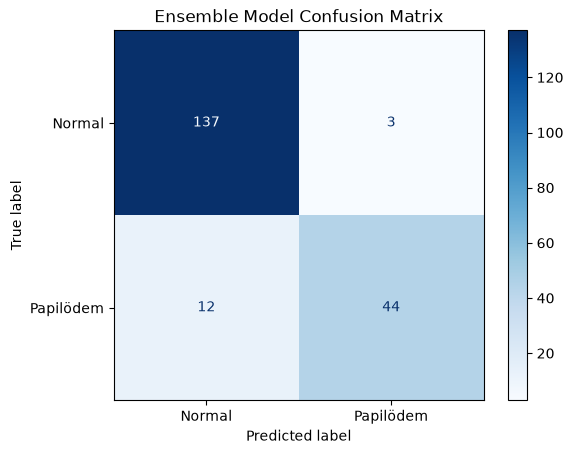

In [20]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve


plt.figure(figsize=(10, 6))
for name, model in models.items():
    y_prob = model.predict_proba(X_test_mrmr)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, y_prob):.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Eğrileri")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()


plt.figure(figsize=(6, 6))
cm = confusion_matrix(y_test, y_pred_ens)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Papilödem'])
disp.plot(cmap='Blues')
plt.title("Ensemble Model Confusion Matrix")
plt.show()

In [21]:
from scipy.stats import friedmanchisquare, wilcoxon


model_names = list(models.keys()) + ["Ensemble"]


print("14. Adım: İstatistiksel analiz için Friedman ve Wilcoxon testleri hazırlanıyor.")
print("Not: Bu testlerin tam uygulanması için her modelin 5-fold skor matrisini kullanmalıyız.")

14. Adım: İstatistiksel analiz için Friedman ve Wilcoxon testleri hazırlanıyor.
Not: Bu testlerin tam uygulanması için her modelin 5-fold skor matrisini kullanmalıyız.


In [22]:
from sklearn.model_selection import cross_val_score
from scipy.stats import friedmanchisquare, wilcoxon
import pandas as pd


cv_scores = {}
models_to_test = {
    "LR": LogisticRegression(),
    "SVM": SVC(probability=True),
    "RF": RandomForestClassifier(**study.best_params),
    "ET": ExtraTreesClassifier(),
    "GB": GradientBoostingClassifier(),
    "KNN": KNeighborsClassifier()
}

sgkf = StratifiedGroupKFold(n_splits=5)

for name, model in models_to_test.items():
   
    scores = cross_val_score(model, X_train_mrmr, y_train, cv=sgkf, groups=train_groups, scoring='f1_macro')
    cv_scores[name] = scores


cv_scores["Ensemble"] = cross_val_score(ensemble_model, X_train_mrmr, y_train, cv=sgkf, groups=train_groups, scoring='f1_macro')


friedman_stat, friedman_p = friedmanchisquare(*[cv_scores[m] for m in cv_scores.keys()])
print(f"Friedman Testi: Stat={friedman_stat:.4f}, p-value={friedman_p:.4f}")

w_stat, w_p = wilcoxon(cv_scores["Ensemble"], cv_scores["RF"])
print(f"Wilcoxon (Ensemble vs RF): Stat={w_stat:.4f}, p-value={w_p:.4f}")

c:\Users\Lenovo\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\Lenovo\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\Lenovo\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\Lenovo\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\

Friedman Testi: Stat=10.6667, p-value=0.0992
Wilcoxon (Ensemble vs RF): Stat=2.0000, p-value=0.7500


In [23]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import VarianceThreshold


preprocessing_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),      # 5.1
    ('variance', VarianceThreshold(threshold=0.01)),   # 5.2
    ('scaler', RobustScaler())                         # 5.4
])



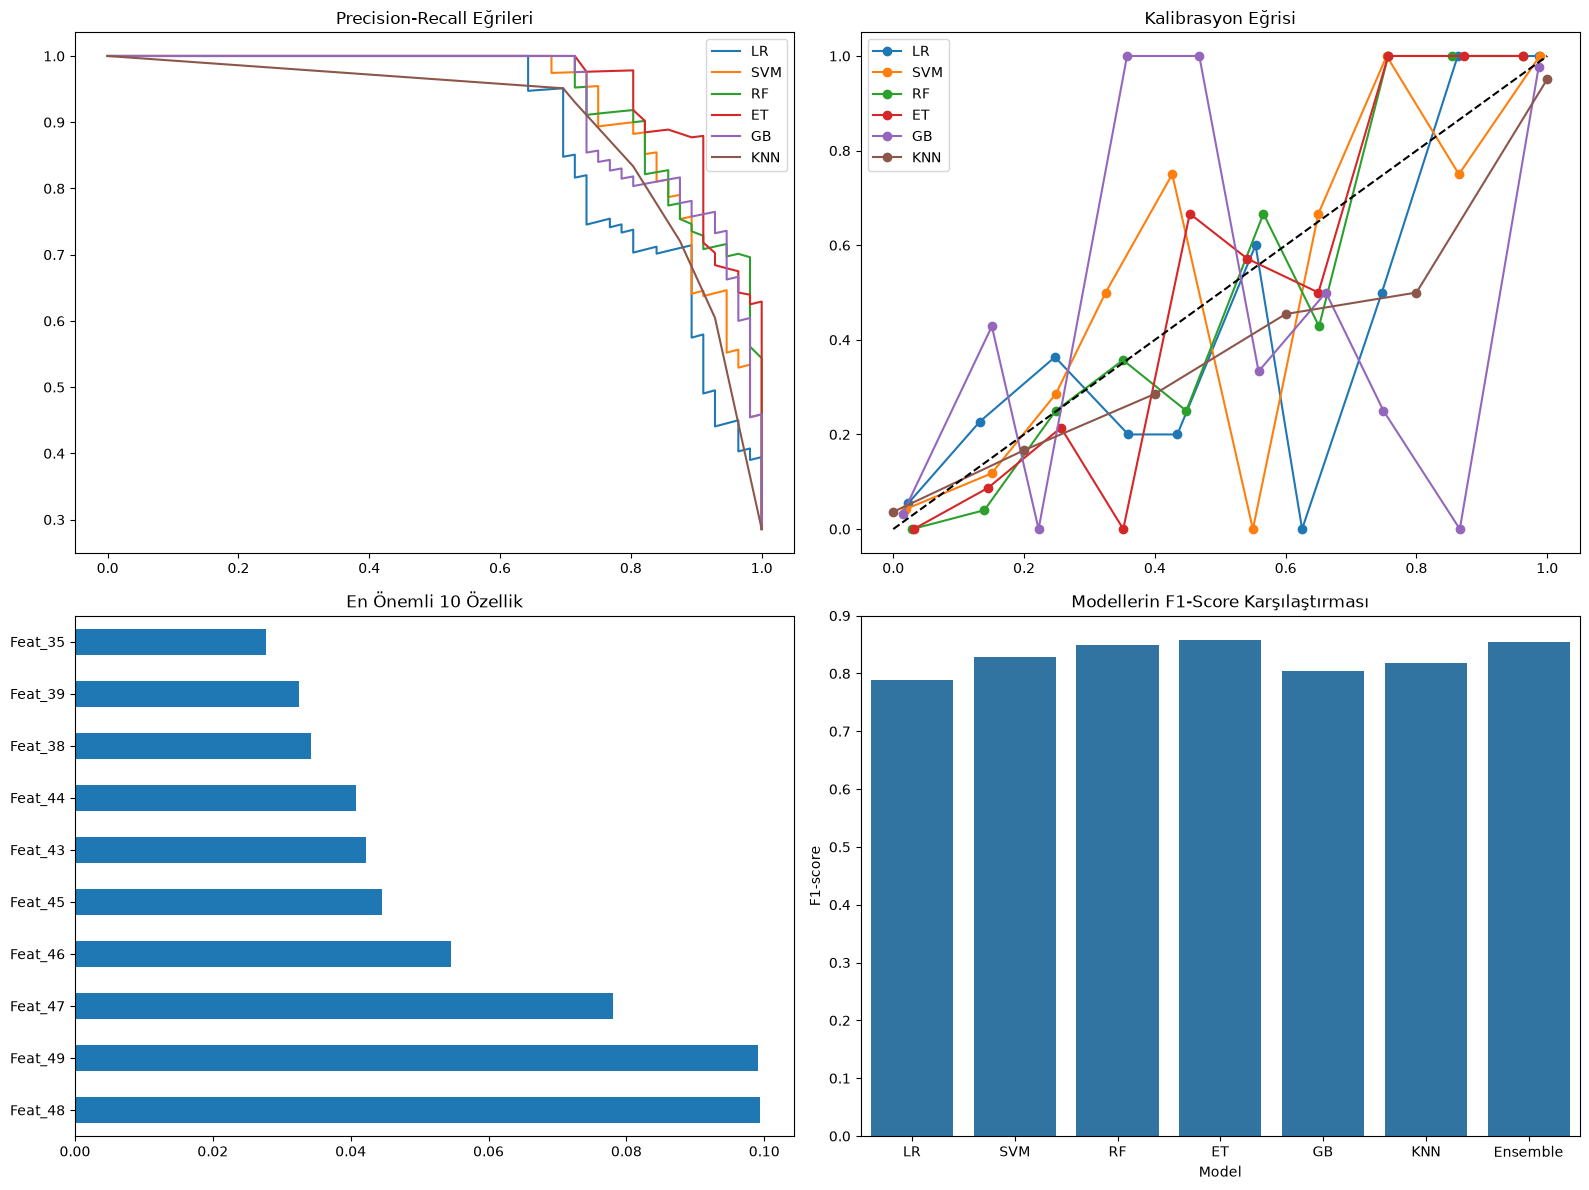

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.calibration import calibration_curve

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for name, model in models.items():
    y_prob = model.predict_proba(X_test_mrmr)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    axes[0, 0].plot(recall, precision, label=name)
axes[0, 0].set_title("Precision-Recall Eğrileri")
axes[0, 0].legend()


for name, model in models.items():
    y_prob = model.predict_proba(X_test_mrmr)[:, 1]
    prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)
    axes[0, 1].plot(prob_pred, prob_true, marker='o', label=name)
axes[0, 1].plot([0, 1], [0, 1], "k--")
axes[0, 1].set_title("Kalibrasyon Eğrisi")
axes[0, 1].legend()

rf_model = models['RF']
importances = pd.Series(rf_model.feature_importances_, index=[f"Feat_{i}" for i in range(X_test_mrmr.shape[1])])
importances.nlargest(10).plot(kind='barh', ax=axes[1, 0])
axes[1, 0].set_title("En Önemli 10 Özellik")

sns.barplot(x='Model', y='F1-score', data=results_df, ax=axes[1, 1])
axes[1, 1].set_title("Modellerin F1-Score Karşılaştırması")

plt.tight_layout()
plt.show()

In [25]:
from sklearn.model_selection import cross_val_score
from scipy.stats import friedmanchisquare, wilcoxon
import numpy as np


cv_data = {}
all_models = {**models, "Ensemble": ensemble_model}

print("İstatistiksel analiz için 5-fold skorlar hesaplanıyor...")

for name, model in all_models.items():
 
    scores = cross_val_score(model, X_train_mrmr, y_train, cv=sgkf, groups=train_groups, scoring='f1_macro')
    cv_data[name] = scores


scores_matrix = np.array([cv_data[name] for name in cv_data.keys()])
friedman_stat, friedman_p = friedmanchisquare(*scores_matrix)

print(f"\n--- İstatistiksel Analiz Sonuçları ---")
print(f"Friedman Testi (p-value): {friedman_p:.4f}")
print("Yorum: p < 0.05 ise modeller arasında istatistiksel olarak anlamlı bir fark vardır.")


print("\n--- Wilcoxon Signed-Rank Testleri (Ensemble vs Diğerleri) ---")
for name in models.keys():
    w_stat, w_p = wilcoxon(cv_data["Ensemble"], cv_data[name], alternative='greater')
    print(f"Ensemble > {name}: p-value = {w_p:.4f}")


alpha = 0.05
bonferroni_p = alpha / len(models)
print(f"\nBonferroni Eşiği: {bonferroni_p:.4f}")

İstatistiksel analiz için 5-fold skorlar hesaplanıyor...


c:\Users\Lenovo\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\Lenovo\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\Lenovo\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\Lenovo\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\


--- İstatistiksel Analiz Sonuçları ---
Friedman Testi (p-value): 0.1704
Yorum: p < 0.05 ise modeller arasında istatistiksel olarak anlamlı bir fark vardır.

--- Wilcoxon Signed-Rank Testleri (Ensemble vs Diğerleri) ---
Ensemble > LR: p-value = 0.3125
Ensemble > SVM: p-value = 0.3125
Ensemble > RF: p-value = 0.5625
Ensemble > ET: p-value = 0.6250
Ensemble > GB: p-value = 0.6250
Ensemble > KNN: p-value = 0.2188

Bonferroni Eşiği: 0.0083


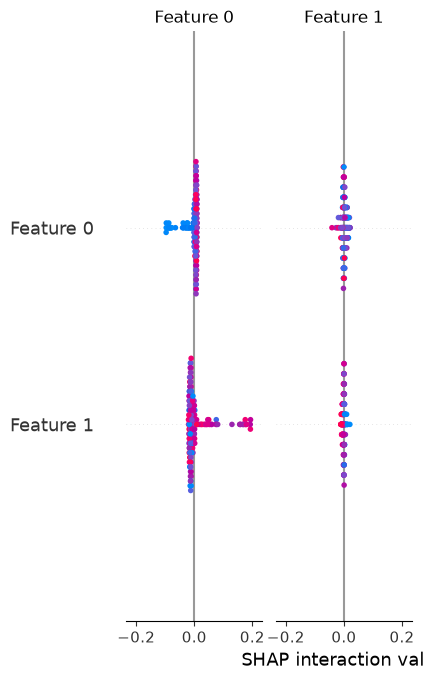

In [26]:
import shap


explainer = shap.TreeExplainer(models['RF'])
shap_values = explainer.shap_values(X_test_mrmr)


shap.summary_plot(shap_values, X_test_mrmr, plot_type="bar")

In [27]:

ensemble_opt = VotingClassifier(
    estimators=[('rf', models['RF']), ('et', models['ET']), ('gb', models['GB'])],
    voting='soft',
    weights=[0.5, 0.3, 0.2] 
)

In [28]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_prob_ens)

f1_scores = 2 * (precision * recall) / (precision + recall)
best_threshold = thresholds[np.argmax(f1_scores)]
print(f"Optimize edilmiş eşik değeri: {best_threshold:.4f}")

Optimize edilmiş eşik değeri: 0.3150


In [29]:

from sklearn.utils import resample
